In [77]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import glob

from scripts.postprocess import read_jsondir_to_df, to_complex
from scripts.postprocess import filter_df 

67


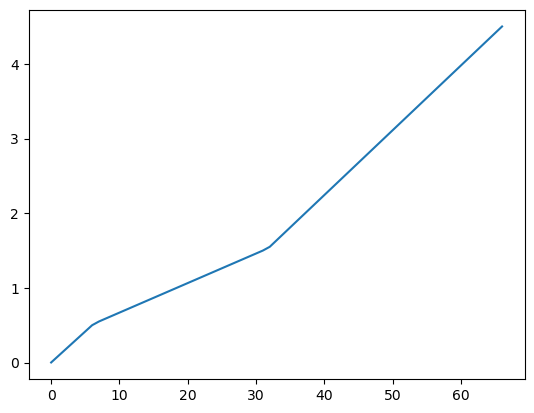

In [78]:
mu_arr = np.concatenate([
            np.linspace(0.001, 0.5, 7),
            np.linspace(0.55, 1.5, 25),
            np.linspace(1.55, 4.5, 35)
        ])  # length 67
print(len(mu_arr))
plt.plot(mu_arr)

In [79]:
free_tol= 1

In [80]:
# df = pd.read_json('data.json')
# df_filtered = filter_df(df, tol=1e-6)
# df_filtered.iloc[:]


In [81]:
path = "./data/muT_V15_bulk"
df = read_jsondir_to_df(path)
df_filtered = filter_df(df, tol=1e-6)

df_filtered.iloc[0:40]

,mu,T,best_free,free,F_onsite,F_swave,F_dwave,F_px,F_py,Fuu_px,Fuu_py,Fdd_px,Fdd_py
0,0.001,0.001000,-17089.897531,-17089.897531,0,0,"{'imag': -1.371186903e-18, 'real': 0.102975797...",0,0,0,0,0,0
1,0.001,0.008667,-17089.880626,-17089.880626,0,0,"{'imag': 0.0, 'real': 0.1029780869}",0,0,0,0,0,0
2,0.001,0.016333,-17089.853448,-17089.853448,0,0,"{'imag': 0.0, 'real': 0.1029704661}",0,0,0,0,0,0
3,0.001,0.024000,-17089.784032,-17089.784032,0,0,"{'imag': 0.0, 'real': 0.1029557197}",0,0,0,0,0,0
4,0.001,0.031667,-17089.666442,-17089.666439,0,0,"{'imag': 0.0, 'real': 0.1029314526}",0,0,0,0,0,0
5,0.001,0.039333,-17089.474762,-17089.474762,0,0,"{'imag': 0.0, 'real': 0.10289307090000001}",0,0,0,0,0,0
6,0.001,0.047000,-17089.172366,-17089.172366,0,0,"{'imag': 0.0, 'real': 0.102834956}",0,0,0,0,0,0
7,0.001,0.054667,-17088.705639,-17088.705639,0,0,"{'imag': 0.0, 'real': 0.1027499776}",0,0,0,0,0,0
8,0.001,0.062333,-17087.997466,-17087.997466,0,0,"{'imag': 0.0, 'real': 0.10262878830000001}",0,0,0,0,0,0
9,0.001,0.070000,-17086.947700,-17086.947700,0,0,"{'imag': 0.0, 'real': 0.1024596811}",0,0,0,0,0,0


In [82]:
import numpy as np
import pandas as pd

def canonical_phase_string_from_row(row, tol=1e-8):
    """
    Canonicalize the phase content of one row.

    Rules:
    1. real/imag parts are detected from F_onsite, F_swave, F_dwave, F_px, F_py
    2. phase + i phase -> phase   (e.g. d + id -> d)
    3. global phase rotations are discarded:
       choose the representative where the leftmost present component is real
    4. F_onsite and F_swave both map to 's'
    """

    # Canonical order
    bases = ["s", "d", "px", "py"]

    # Collect whether each base has real and/or imaginary part present
    comp = {b: {"r": False, "i": False} for b in bases}

    source_map = [
        ("F_onsite", "s"),
        ("F_swave",  "s"),
        ("F_dwave",  "d"),
        ("F_px",     "px"),
        ("F_py",     "py"),
    ]

    for col, base in source_map:
        val = to_complex(row[col])
        if pd.isna(val):
            val = 0

        if np.abs(np.real(val)) > tol:
            comp[base]["r"] = True
        if np.abs(np.imag(val)) > tol:
            comp[base]["i"] = True

    # Rule 1: phase + i phase == phase
    # If both real and imag are present in same channel, collapse to just real representative.
    for b in bases:
        if comp[b]["r"] and comp[b]["i"]:
            comp[b]["i"] = False

    # Determine which channels are present at all
    present = [b for b in bases if comp[b]["r"] or comp[b]["i"]]
    if not present:
        return "normal"

    # Rule 2: remove global phase by forcing the leftmost present component to be real.
    # If leftmost present component is imaginary-only, multiply everything by -i:
    # real <-> imag for presence purposes.
    left = present[0]
    if comp[left]["i"] and not comp[left]["r"]:
        rotated = {b: {"r": False, "i": False} for b in bases}
        for b in bases:
            # Under multiplication by -i: real presence -> imag presence, imag presence -> real presence
            rotated[b]["r"] = comp[b]["i"]
            rotated[b]["i"] = comp[b]["r"]
        comp = rotated

        # After rotation, again collapse phase + i phase -> phase
        for b in bases:
            if comp[b]["r"] and comp[b]["i"]:
                comp[b]["i"] = False

    # Build canonical ordered label
    labels = []
    for b in bases:
        if comp[b]["r"]:
            labels.append(b)
        elif comp[b]["i"]:
            labels.append("i" + b)

    return " + ".join(labels) if labels else "normal"

In [83]:
df_phase = df_filtered.copy()
df_phase["phase"] = df_phase.apply(canonical_phase_string_from_row, axis=1)

In [84]:
df_phase.iloc[0:10]

,mu,T,best_free,free,F_onsite,F_swave,F_dwave,F_px,F_py,Fuu_px,Fuu_py,Fdd_px,Fdd_py,phase
0,0.001,0.001000,-17089.897531,-17089.897531,0,0,"{'imag': -1.371186903e-18, 'real': 0.102975797...",0,0,0,0,0,0,d
1,0.001,0.008667,-17089.880626,-17089.880626,0,0,"{'imag': 0.0, 'real': 0.1029780869}",0,0,0,0,0,0,d
2,0.001,0.016333,-17089.853448,-17089.853448,0,0,"{'imag': 0.0, 'real': 0.1029704661}",0,0,0,0,0,0,d
3,0.001,0.024000,-17089.784032,-17089.784032,0,0,"{'imag': 0.0, 'real': 0.1029557197}",0,0,0,0,0,0,d
4,0.001,0.031667,-17089.666442,-17089.666439,0,0,"{'imag': 0.0, 'real': 0.1029314526}",0,0,0,0,0,0,d
5,0.001,0.039333,-17089.474762,-17089.474762,0,0,"{'imag': 0.0, 'real': 0.10289307090000001}",0,0,0,0,0,0,d
6,0.001,0.047000,-17089.172366,-17089.172366,0,0,"{'imag': 0.0, 'real': 0.102834956}",0,0,0,0,0,0,d
7,0.001,0.054667,-17088.705639,-17088.705639,0,0,"{'imag': 0.0, 'real': 0.1027499776}",0,0,0,0,0,0,d
8,0.001,0.062333,-17087.997466,-17087.997466,0,0,"{'imag': 0.0, 'real': 0.10262878830000001}",0,0,0,0,0,0,d
9,0.001,0.070000,-17086.947700,-17086.947700,0,0,"{'imag': 0.0, 'real': 0.1024596811}",0,0,0,0,0,0,d


In [85]:
df_phase["min_free_at_point"] = df_phase.groupby(["mu", "T"])["free"].transform("min")

df_deg = df_phase[
    np.abs(df_phase["free"] - df_phase["min_free_at_point"]) <= free_tol
].copy()

In [86]:
def combine_degenerate_phases(phases):
    return " | ".join(sorted(set(phases)))

df_plot = (
    df_deg.groupby(["mu", "T"], as_index=False)
    .agg(
        phase=("phase", combine_degenerate_phases),
        free=("free", "min"),
    )
)

In [87]:
df_plot.iloc[300:320]

,mu,T,phase,free
300,0.55,0.154333,d,-17377.146049
301,0.55,0.162000,d,-17361.923672
302,0.55,0.169667,d,-17345.649323
303,0.55,0.177333,d,-17328.349493
304,0.55,0.185000,d,-17310.052163
305,0.55,0.192667,d,-17290.785987
306,0.55,0.200333,d,-17270.581486
307,0.55,0.208000,d,-17249.468006
308,0.55,0.215667,d,-17232.316246
309,0.55,0.223333,normal,-17252.465774


In [88]:
phase_order = sorted(df_plot["phase"].unique())
phase_to_id = {phase: i for i, phase in enumerate(phase_order)}
id_to_phase = {i: phase for phase, i in phase_to_id.items()}

df_plot["phase_id"] = df_plot["phase"].map(phase_to_id)

phase_grid = df_plot.pivot(index="T", columns="mu", values="phase_id").sort_index()

In [89]:
phase_grid_filled = phase_grid.ffill(axis=0)

In [90]:
T_vals = phase_grid.index.to_numpy()
mu_vals = phase_grid.columns.to_numpy()
Z = phase_grid.to_numpy()

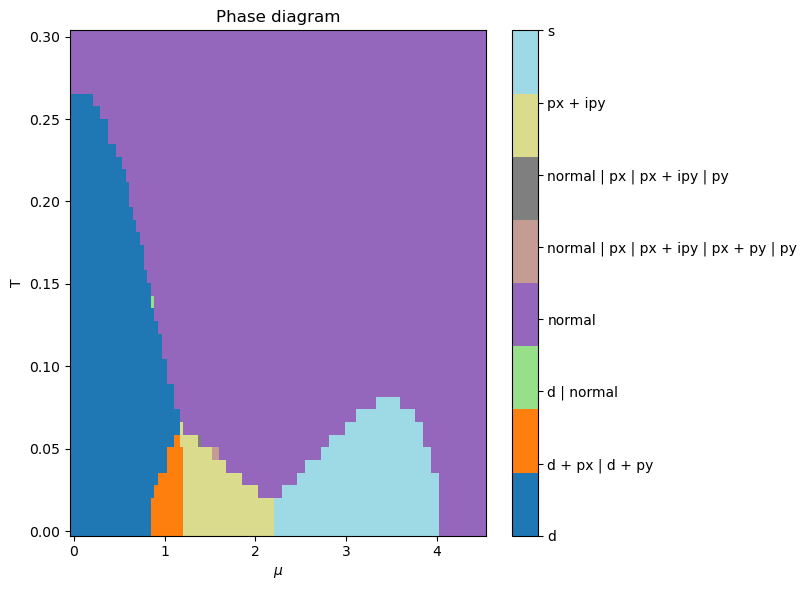

In [99]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(plt.cm.tab20(np.linspace(0, 1, len(phase_order))))

plt.figure(figsize=(8, 6))
mesh = plt.pcolormesh(mu_vals, T_vals, Z, shading="nearest", cmap=cmap)

cbar = plt.colorbar(mesh, ticks=np.arange(len(phase_order)))
cbar.ax.set_yticklabels(phase_order)

plt.xlabel(r"$\mu$")
plt.ylabel("T")
plt.title("Phase diagram")
# plt.ylim(0.01,0.3)
plt.tight_layout()
plt.show()

In [92]:
# Find all grid points where the phase is NOT normal,
# but at least one neighbor IS normal

dwave_idx = phase_order.index("d")
is_normal = (Z == dwave_idx)

# Check 4-connectivity neighbors
from scipy.ndimage import binary_dilation

# Dilate the normal region by 1 cell
dilated_normal = binary_dilation(is_normal)

# Boundary = non-normal cells that touch a normal cell
boundary_mask = (~is_normal) & dilated_normal

# Extract the (mu, T) pairs
T_grid, mu_grid = np.meshgrid(T_vals, mu_vals, indexing='ij')
boundary_mu = mu_grid[boundary_mask]
boundary_T  = T_grid[boundary_mask]

boundary_points = np.column_stack([boundary_mu, boundary_T])



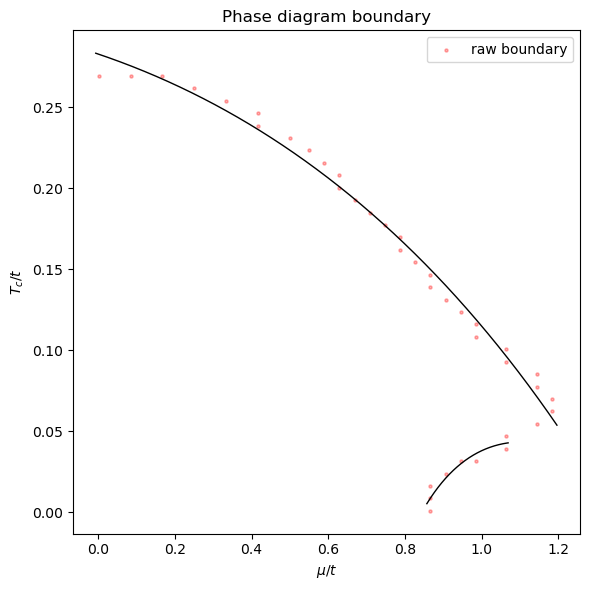

In [93]:
from scipy.interpolate import splprep, splev
plt.figure(figsize=(6, 6))

# Sort points by mu for a clean parametric curve
idx = np.argsort(boundary_mu)
mu_sorted = boundary_mu[idx]
T_sorted  = boundary_T[idx]

# Fit a parametric spline (s controls smoothness)
tck, u = splprep([mu_sorted[np.where(T_sorted>=0.05)], T_sorted[np.where(T_sorted>=0.05)]], s=0.5, k=2)

# Evaluate on a fine grid
u_fine = np.linspace(0, 1, 1000)
mu_smooth, T_smooth = splev(u_fine, tck)
plt.plot(mu_smooth, T_smooth, 'k-', linewidth=1.)

tck, u = splprep([mu_sorted[np.where(T_sorted<=0.05)], T_sorted[np.where(T_sorted<=0.05)]], s=0.5, k=2)

# Evaluate on a fine grid
u_fine = np.linspace(0, 1, 1000)
mu_smooth, T_smooth = splev(u_fine, tck)
plt.plot(mu_smooth, T_smooth, 'k-', linewidth=1.)

# Plot
plt.scatter(boundary_mu, boundary_T, s=5, c='red', alpha=0.3, label='raw boundary')
plt.xlabel(r"$\mu/t$")
plt.ylabel(r"$T_c/t$")
plt.title("Phase diagram boundary")
plt.legend()
plt.tight_layout()
plt.show()

In [94]:
from scipy.ndimage import zoom

# upsample for smooth appearance
Z_smooth = zoom(Z, 4, order=0)  # order=0 keeps phases discrete
mu_smooth = np.linspace(mu_vals.min(), mu_vals.max(), Z_smooth.shape[1])
T_smooth = np.linspace(T_vals.min(), T_vals.max(), Z_smooth.shape[0])

In [95]:

mu_arr = np.linspace(0.025, 1.5, 50)
T_arr = np.linspace(0.01, 0.8, 50)
print(T_arr)
print(mu_arr)

[0.01       0.02612245 0.0422449  0.05836735 0.0744898  0.09061224
 0.10673469 0.12285714 0.13897959 0.15510204 0.17122449 0.18734694
 0.20346939 0.21959184 0.23571429 0.25183673 0.26795918 0.28408163
 0.30020408 0.31632653 0.33244898 0.34857143 0.36469388 0.38081633
 0.39693878 0.41306122 0.42918367 0.44530612 0.46142857 0.47755102
 0.49367347 0.50979592 0.52591837 0.54204082 0.55816327 0.57428571
 0.59040816 0.60653061 0.62265306 0.63877551 0.65489796 0.67102041
 0.68714286 0.70326531 0.71938776 0.7355102  0.75163265 0.7677551
 0.78387755 0.8       ]
[0.025      0.05510204 0.08520408 0.11530612 0.14540816 0.1755102
 0.20561224 0.23571429 0.26581633 0.29591837 0.32602041 0.35612245
 0.38622449 0.41632653 0.44642857 0.47653061 0.50663265 0.53673469
 0.56683673 0.59693878 0.62704082 0.65714286 0.6872449  0.71734694
 0.74744898 0.77755102 0.80765306 0.8377551  0.86785714 0.89795918
 0.92806122 0.95816327 0.98826531 1.01836735 1.04846939 1.07857143
 1.10867347 1.13877551 1.16887755 1.1989